In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


### Library Imports

This cell imports essential Python libraries for data manipulation, numerical operations, and visualization. `pandas` is used for data structures and analysis, `numpy` for numerical computing, and `matplotlib.pyplot` for plotting. It also configures `warnings` to ignore non-critical messages, ensuring cleaner output.

In [29]:
from google.colab import files
import io

print("Please upload your 'Agriculture_price_dataset.csv' file:")
uploaded = files.upload()

Please upload your 'Agriculture_price_dataset.csv' file:


Saving Agriculture_price_dataset.csv to Agriculture_price_dataset (1).csv


### File Upload for Dataset

This cell facilitates the direct upload of your dataset into the Colab environment. Upon execution, an upload button will appear, allowing you to select your `Agriculture_price_dataset.csv` file from your local machine. This method replaces the need for mounting Google Drive, providing a straightforward way to load data for analysis.

In [30]:
# Assuming the uploaded file is 'Agriculture_price_dataset.csv'
# Get the filename from the uploaded dictionary
uploaded_filename = list(uploaded.keys())[0]

# Load the dataset from the uploaded file into a pandas DataFrame
df_from_drive = pd.read_csv(io.BytesIO(uploaded[uploaded_filename]))
print(f"✅ Dataset '{uploaded_filename}' loaded!")

✅ Dataset 'Agriculture_price_dataset (1).csv' loaded!


In [31]:
df = df_from_drive.copy() # Use the DataFrame loaded from the uploaded file
print(f"✅ Dataset loaded!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df.head())

✅ Dataset loaded!
Rows: 737392
Columns: 10

Column Names:
['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date']

First 5 rows:


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/06/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/06/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/06/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/06/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/06/2023


### Initial Data Loading and Overview

This cell initializes the main `df` DataFrame by copying the data from `df_from_drive` (which was loaded via the file upload). It then provides a concise overview of the dataset's characteristics, including the total number of rows and columns, a list of all column names, and the first five rows of the data to give an initial glimpse of its structure and content.

In [32]:
# Convert the 'Price Date' column to datetime objects
# dayfirst=True is often safer for Indian datasets (DD/MM/YYYY format)
df['Price Date'] = pd.to_datetime(df['Price Date'], dayfirst=True, format='mixed')

# Now check the range again
print(f"From: {df['Price Date'].min()}")
print(f"To:   {df['Price Date'].max()}")

From: 2023-01-07 00:00:00
To:   2025-12-05 00:00:00


### Converting 'Price Date' to Datetime Objects

This cell focuses on data type conversion for the 'Price Date' column. It uses `pd.to_datetime()` to convert the date strings into datetime objects, which is essential for time-series analysis. The `dayfirst=True` argument helps correctly parse dates in DD/MM/YYYY format, and `format='mixed'` allows for flexible parsing. Finally, it prints the minimum and maximum dates to confirm the successful conversion and range of the dataset.

In [33]:
# Check crops, states, missing values
print("=== UNIQUE CROPS ===")
print(df['Commodity'].value_counts())

print("\n=== UNIQUE STATES ===")
print(f"Total states: {df['STATE'].nunique()}")

print("\n=== DATE RANGE ===")
print(f"From: {df['Price Date'].min()}")
print(f"To:   {df['Price Date'].max()}")

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== PRICE STATS ===")
print(df['Modal_Price'].describe())

=== UNIQUE CROPS ===
Commodity
Potato    327332
Onion     298658
Wheat      76976
Tomato     26644
Rice        7782
Name: count, dtype: int64

=== UNIQUE STATES ===
Total states: 30

=== DATE RANGE ===
From: 2023-01-07 00:00:00
To:   2025-12-05 00:00:00

=== MISSING VALUES ===
STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
dtype: int64

=== PRICE STATS ===
count    737392.000000
mean       2474.484638
std        2023.851909
min           0.000000
25%        1300.000000
50%        2150.000000
75%        3000.000000
max      460000.000000
Name: Modal_Price, dtype: float64


### Data Exploration and Summary Statistics

This cell performs various exploratory data analysis (EDA) checks. It first displays the unique counts of different commodities and the total number of unique states. Then, it confirms the date range of the dataset. Crucially, it checks for any missing values across all columns and provides descriptive statistics for the 'Modal_Price' column, offering insights into its distribution, central tendency, and spread.

In [34]:
print(f"Total Crops: {df['Commodity'].nunique()}")

Total Crops: 5


### Counting Unique Commodities

This cell calculates and prints the total number of distinct commodities present in the dataset. This helps in understanding the diversity of agricultural products covered by the data.

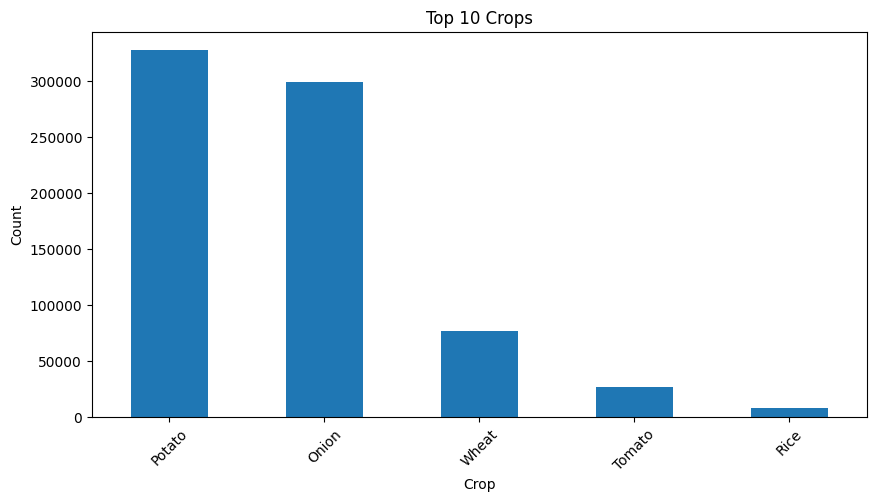

In [35]:
df['Commodity'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Crops")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Visualization of Top 10 Crops

This cell generates a bar plot to visually represent the frequency of the top 10 most common commodities in the dataset. It uses `value_counts()` to count occurrences and `plot(kind='bar')` for visualization, providing a quick insight into the most traded crops.

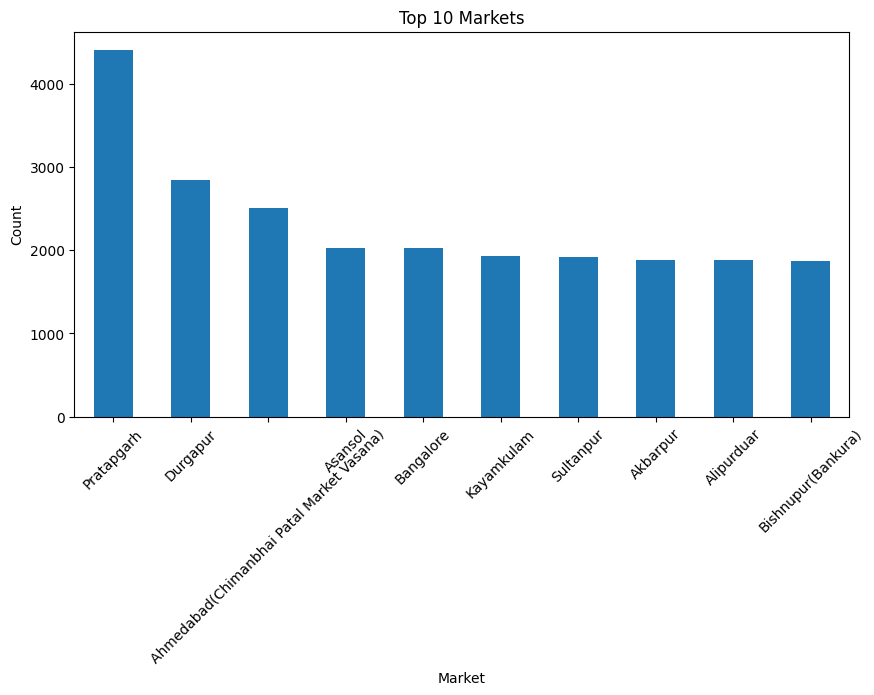

In [36]:
df['Market Name'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Markets")
plt.xlabel("Market")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Visualization of Top 10 Markets

Similar to the crop visualization, this cell creates a bar plot showing the top 10 markets with the highest number of records. This helps identify the most active or frequently reported markets in the dataset.

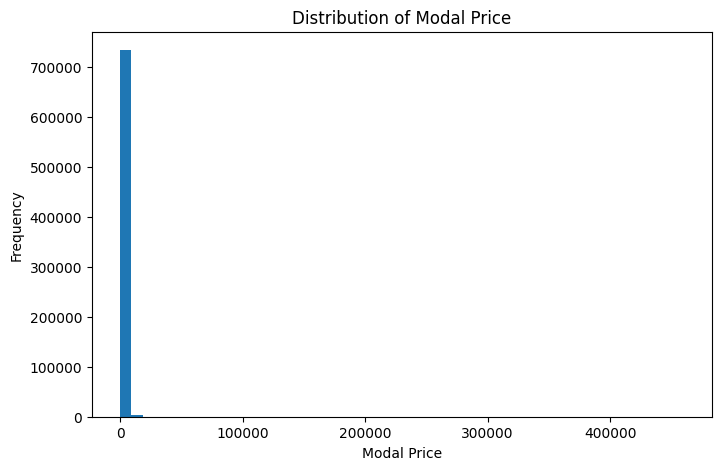

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df['Modal_Price'], bins=50)
plt.title("Distribution of Modal Price")
plt.xlabel("Modal Price")
plt.ylabel("Frequency")
plt.show()

### Distribution of Modal Price

This cell generates a histogram to visualize the distribution of the 'Modal_Price' column. A histogram helps in understanding the frequency of different price ranges and identifying any skewness, outliers, or common price points within the data.

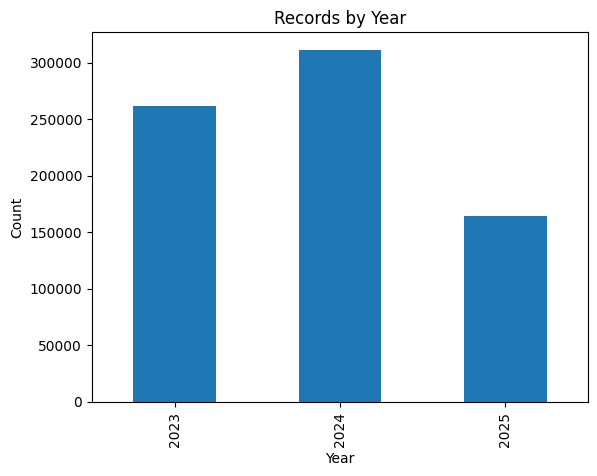

In [38]:
df['Year'] = df['Price Date'].dt.year

df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title("Records by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### Records by Year

This cell extracts the 'Year' from the 'Price Date' column and then creates a bar plot to show the number of records available for each year. This visualization helps in understanding the temporal coverage and density of the dataset over different years.

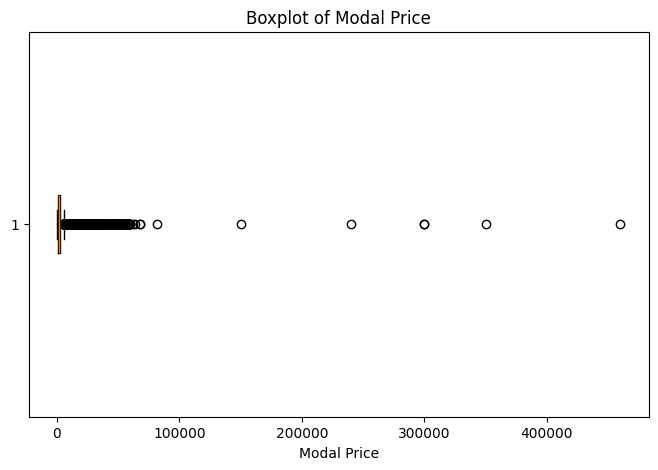

In [39]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Modal_Price'], vert=False)
plt.title("Boxplot of Modal Price")
plt.xlabel("Modal Price")
plt.show()

### Boxplot of Modal Price

This cell displays a horizontal boxplot for the 'Modal_Price' column. A boxplot is excellent for visualizing the distribution of a numerical variable, showing the median, quartiles, and potential outliers, offering a quick summary of price variability.

In [40]:
print("Highest Price:", df['Modal_Price'].max())
print("Lowest Price:", df['Modal_Price'].min())

Highest Price: 460000.0
Lowest Price: 0.0


### Identifying Highest and Lowest Modal Prices

This cell simply prints the maximum and minimum values found in the 'Modal_Price' column. This provides a direct insight into the absolute highest and lowest prices recorded in the dataset.

In [41]:
df.nlargest(10, 'Modal_Price')[['Commodity','STATE','Market Name','Modal_Price']]


,Commodity,STATE,Market Name,Modal_Price
207832,Onion,Bihar,Jehanabad,460000.0
249500,Onion,Bihar,Jehanabad,350000.0
606873,Onion,Bihar,Jehanabad,300000.0
610350,Onion,Bihar,Jehanabad,300000.0
312916,Onion,Bihar,Jehanabad,240000.0
42064,Tomato,Madhya Pradesh,Katni(F&V),150000.0
78115,Tomato,Meghalaya,Sohra,82000.0
64409,Tomato,Meghalaya,Sohra,68000.0
89821,Tomato,Meghalaya,Sohra,68000.0
256706,Onion,Bihar,Patna (Musallahpur),64000.0


### Top 10 Highest Modal Prices

This cell identifies and displays the top 10 records with the highest 'Modal_Price'. It specifically shows the 'Commodity', 'STATE', 'Market Name', and 'Modal_Price' for these high-value instances, allowing for a quick inspection of outlier high prices and their contexts.

In [42]:
df[df['Modal_Price'] > 50000].shape

(61, 11)

### Filtering Data for High Prices

This cell filters the DataFrame to include only records where the 'Modal_Price' is greater than 50,000. It then prints the shape of this filtered DataFrame, indicating how many such high-priced records exist in the dataset.

In [43]:
df[df['Modal_Price'] > 50000][['Commodity','STATE','Market Name','Modal_Price']].head(20)

,Commodity,STATE,Market Name,Modal_Price
42064,Tomato,Madhya Pradesh,Katni(F&V),150000.0
42363,Tomato,Kerala,Pothencode,60040.0
44862,Tomato,Kerala,Pothencode,54040.0
55748,Tomato,Kerala,Pothencode,60040.0
56731,Tomato,Kerala,Pothencode,54040.0
63835,Potato,Meghalaya,Sohra,58009.0
64409,Tomato,Meghalaya,Sohra,68000.0
77636,Potato,Meghalaya,Sohra,58000.0
78115,Tomato,Meghalaya,Sohra,82000.0
89821,Tomato,Meghalaya,Sohra,68000.0


### Displaying High-Priced Commodities

This cell extends the previous filtering by displaying the first 20 records where the 'Modal_Price' exceeds 50,000. It shows the 'Commodity', 'STATE', 'Market Name', and 'Modal_Price' for these instances, providing more detailed information about the high-value transactions.